In [1]:
import pandas as pd

# We use windows-1252 or latin1 to handle the special characters in this specific dataset
try:
    df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')
    print("✅ Success! Data loaded.")
    display(df.head())
except Exception as e:
    print(f"❌ Error: {e}")

✅ Success! Data loaded.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


<Axes: xlabel='month'>

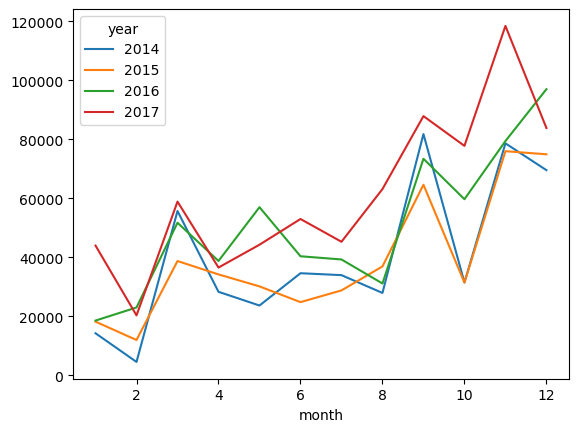

In [22]:
pivot = monthly_sales.pivot(index='month', columns='year', values='Sales')
pivot.plot()

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

<Axes: xlabel='Order Date'>

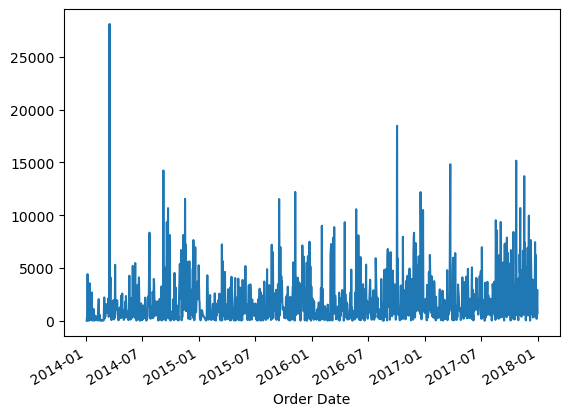

In [12]:
df.groupby('Order Date')['Sales'].sum().plot()

In [13]:
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month

In [14]:
monthly_sales = df.groupby(['year','month'])['Sales'].sum().reset_index()
monthly_sales

,year,month,Sales
0,2014,1,14236.8950
1,2014,2,4519.8920
2,2014,3,55691.0090
3,2014,4,28295.3450
4,2014,5,23648.2870
5,2014,6,34595.1276
6,2014,7,33946.3930
7,2014,8,27909.4685
8,2014,9,81777.3508
9,2014,10,31453.3930


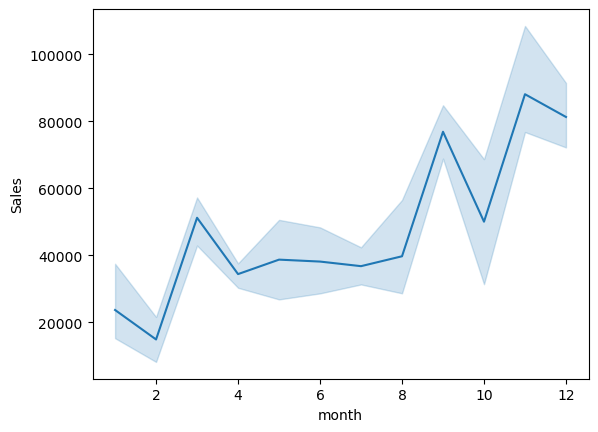

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x='month', y='Sales', data=monthly_sales)
plt.show()

In [17]:
X = monthly_sales[['year','month']]
y = monthly_sales['Sales']

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
df['day'] = df['Order Date'].dt.day

<Axes: xlabel='Order Date'>

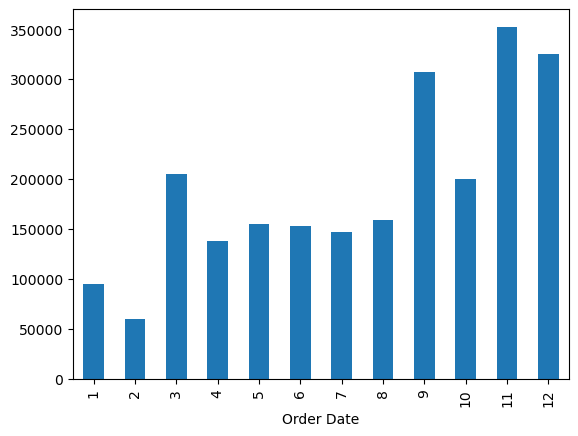

In [27]:
monthly = df.groupby(df['Order Date'].dt.month)['Sales'].sum()
monthly.plot(kind='bar')

In [19]:
future = pd.DataFrame({'year':[2026,2026,2026],
                       'month':[1,2,3]})

pred = model.predict(future)
pred

array([ 96540.17484163, 101777.6490127 , 107015.12318377])

In [25]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X)
mean_absolute_error(y, y_pred)

4117.666962020841

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X, y)

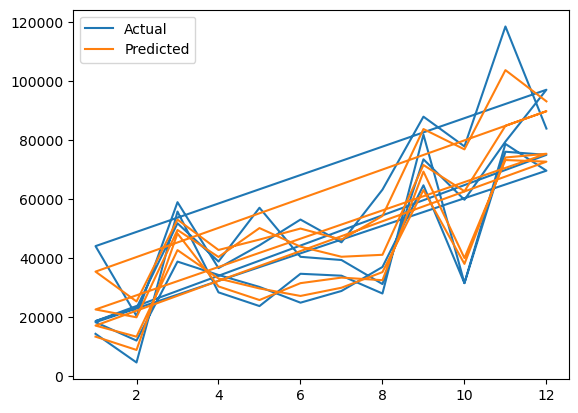

In [26]:
plt.plot(monthly_sales['month'], monthly_sales['Sales'], label='Actual')
plt.plot(monthly_sales['month'], y_pred, label='Predicted')
plt.legend()
plt.show()

In [ ]:
Sales are higher in some months 📈

Certain months show peak demand

Seasonal trend observed

Business can plan stock accordingly

In [ ]:
Model can predict future sales

Helps in better decision making

Useful for inventory & marketing planning